# Preprocesado OCR histórico

67 configuraciones, dos motores y tres imágenes. Este notebook solo lee las mediciones guardadas del 4 de mayo de 2026.

## Método

CER y WER promedian primero los fragmentos de cada imagen y después las tres imágenes con el mismo peso. La normalización elimina tildes, puntuación y mayúsculas, y limita el error a 1. La regla de selección requiere bajar el CER, mejorar al menos dos imágenes y añadir como máximo un segundo de preprocesado. Desempata por menor desviación de CER entre imágenes.

In [1]:
import json
import sys
from pathlib import Path


sys.dont_write_bytecode = True


YELLOW = "\033[33m"


CYAN = "\033[36m"


GREEN = "\033[32m"


RESET = "\033[0m"


PALETTE = (
    "#89b4fa",
    "#cba6f7",
    "#f38ba8",
    "#b4befe",
    "#fab387",
    "#a6e3a1",
    "#f9e2af",
    "#94e2d5",
    "#74c7ec",
    "#eba0ac",
)


def info(text: str, highlight: object = "", after: str = "") -> None:
    """Resalta un dato y devuelve el resto del mensaje al cian."""
    message = text.rstrip(". ")
    if highlight != "":
        message += f" {GREEN}{highlight}{CYAN}"
    if after:
        message += f" {after.rstrip('. ')}"
    print(f"{YELLOW}[*]{RESET} {CYAN}{message}.{RESET}")


def read_json(path: Path) -> dict:
    with path.open(encoding="utf-8-sig") as stream:
        return json.load(stream)


def markdown_table(rows: list[dict], columns: dict[str, str]) -> str:
    from tabulate import tabulate

    return tabulate(
        [
            [
                f"{row[key]:.4f}".rstrip("0").rstrip(".")
                if isinstance(row[key], float)
                else row[key]
                for key in columns
            ]
            for row in rows
        ],
        headers=list(columns.values()),
        tablefmt="github",
        disable_numparse=True,
    )


def show_table(rows: list[dict], columns: dict[str, str]) -> None:
    from IPython.display import Markdown, display

    display(Markdown(markdown_table(rows, columns)))


def plot_metrics(rows: list[dict], metrics: list[tuple[str, str]], title: str):
    """Dos paneles horizontales para conservar etiquetas legibles."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    style = {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.edgecolor": "#bcc2cc",
        "axes.labelcolor": "#414654",
        "xtick.color": "#565e6d",
        "ytick.color": "#252a34",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "svg.fonttype": "none",
    }
    with mpl.rc_context(style):
        height = max(3.7, len(rows) * 0.42 + 1.4)
        figure, axes = plt.subplots(
            1,
            len(metrics),
            figsize=(13, height),
            layout="constrained",
            squeeze=False,
            sharey=True,
        )
        labels = [str(row["label"]) for row in rows]
        colors = [row.get("color", PALETTE[index % len(PALETTE)]) for index, row in enumerate(rows)]
        for axis, (key, caption) in zip(axes[0], metrics, strict=True):
            values = [row[key] for row in rows]
            bars = axis.barh(range(len(labels)), values, color=colors, height=0.64, zorder=3)
            axis.set_yticks(range(len(labels)), labels)
            axis.set_title(caption, loc="left")
            axis.set_axisbelow(True)
            axis.grid(axis="x", color="#e9ebef", linewidth=0.8)
            axis.tick_params(axis="y", length=0, pad=8)
            axis.margins(x=0.2)
            axis.bar_label(
                bars,
                labels=[f"{value:.3f}".rstrip("0").rstrip(".") for value in values],
                padding=5,
                fontsize=9,
            )
        axes[0, 0].set_ylim(len(labels) - 0.5, -0.5)
        figure.suptitle(title, fontsize=15, weight="bold", color="#252a34")
    plt.close(figure)
    return figure


relative = Path("ocr/preprocessing/historico")
here = Path.cwd().resolve()
benchmarks = next(
    parent / "docs/benchmarks"
    for parent in (here, *here.parents)
    if (parent / "docs/benchmarks" / relative / "results.json").is_file()
)

study = benchmarks / relative
data = read_json(study / "results.json")
info("Configuraciones por motor", data["n_tecnicas"])
info("Combinaciones guardadas", len(data["detalle_completo"]))
engine_names = {
    row["motor_id"]: row["motor_nombre"] for row in data["detalle_completo"]
}

[*] Configuraciones por motor 67.
[*] Combinaciones guardadas 402.


## Selección con la regla original

In [2]:
selection = []
for engine, configurations in data["resumen_por_motor"].items():
    eligible = [
        row
        for row in configurations.values()
        if row["tecnica_id"] != "baseline"
        and row["delta_cer"] < 0
        and row["t_preprocesado_s"] <= 1
        and row["mejoras_n"] >= 2
    ]
    winner = min(eligible, key=lambda row: (row["cer_medio"], row["std_cer"]))
    selection.append(dict(winner, engine=engine_names[engine]))

show_table(
    selection,
    {
        "engine": "Motor",
        "tecnica_nombre": "Selección",
        "cer_medio": "CER",
        "delta_cer": "Cambio de CER",
        "mejoras_n": "Imágenes que mejoran",
    },
)

| Motor         | Selección          | CER    | Cambio de CER   | Imágenes que mejoran   |
|---------------|--------------------|--------|-----------------|------------------------|
| PaddleOCR GPU | Nitidez σ=2 α=1.0  | 0.0696 | -0.0396         | 3                      |
| Tesseract     | Resize ×2 + Grises | 0.1181 | -0.0874         | 2                      |

## PaddleOCR GPU

Las cinco configuraciones con menor CER y la base sin preprocesado. La selección anterior aplica también las condiciones de consistencia y coste.

| Configuración             | CER    | WER    | Cambio de CER   | Imágenes que mejoran   | Preprocesado s   | Total s   |
|---------------------------|--------|--------|-----------------|------------------------|------------------|-----------|
| Sin preprocesado          | 0.1092 | 0.1595 | 0               | 0                      | 0.0016           | 12.2027   |
| Nitidez σ=2 α=1.0         | 0.0696 | 0.1172 | -0.0396         | 3                      | 0.0054           | 11.7943   |
| Escala de grises          | 0.072  | 0.1345 | -0.0372         | 2                      | 0.0021           | 12.1072   |
| Morf. erosion k=3         | 0.0734 | 0.1758 | -0.0358         | 2                      | 0.0043           | 11.4399   |
| Bilateral d=9 σc=75 σs=75 | 0.0798 | 0.1464 | -0.0294         | 2                      | 0.0413           | 11.9558   |
| NLM h=5                   | 0.0803 | 0.1305 | -0.0289         | 2                      | 2.9687           | 14.8944   |

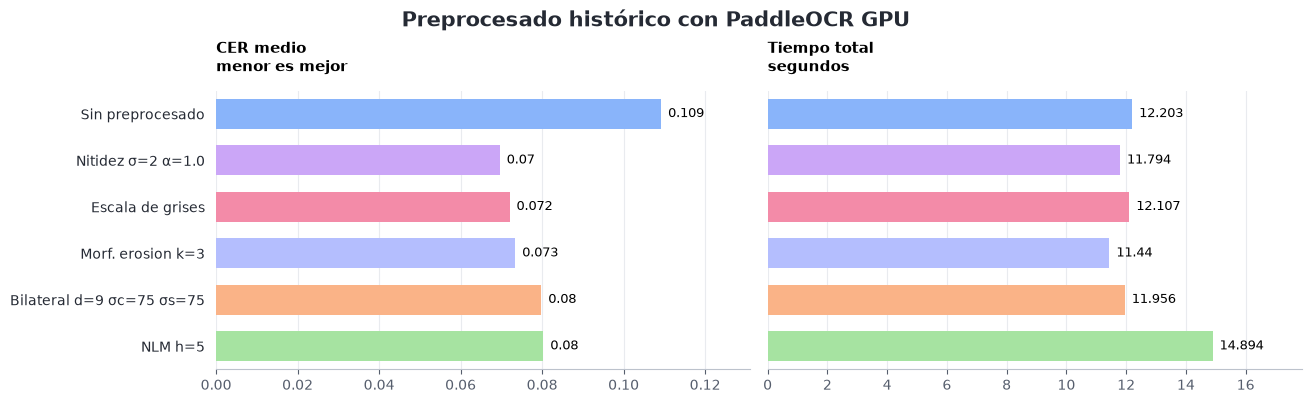

In [3]:
configurations = data["resumen_por_motor"]["paddleocr_gpu"]
ranking = sorted(
    configurations.values(), key=lambda row: (row["cer_medio"], row["std_cer"])
)
rows = [
    configurations["baseline"],
    *[row for row in ranking if row["tecnica_id"] != "baseline"][:5],
]
show_table(
    rows,
    {
        "tecnica_nombre": "Configuración",
        "cer_medio": "CER",
        "wer_medio": "WER",
        "delta_cer": "Cambio de CER",
        "mejoras_n": "Imágenes que mejoran",
        "t_preprocesado_s": "Preprocesado s",
        "velocidad_s": "Total s",
    },
)
figure = plot_metrics(
    [dict(row, label=row["tecnica_nombre"]) for row in rows],
    [
        ("cer_medio", "CER medio\nmenor es mejor"),
        ("velocidad_s", "Tiempo total\nsegundos"),
    ],
    "Preprocesado histórico con PaddleOCR GPU",
)
figure

## Tesseract

Las cinco configuraciones con menor CER y la base sin preprocesado. La selección anterior aplica también las condiciones de consistencia y coste.

| Configuración         | CER    | WER    | Cambio de CER   | Imágenes que mejoran   | Preprocesado s   | Total s   |
|-----------------------|--------|--------|-----------------|------------------------|------------------|-----------|
| Sin preprocesado      | 0.2055 | 0.336  | 0               | 0                      | 0.003            | 8.5859    |
| CLAHE clip=1.0 tile=8 | 0.1056 | 0.1918 | -0.0999         | 1                      | 0.004            | 8.5009    |
| Resize ×2 + Grises    | 0.1181 | 0.2267 | -0.0874         | 2                      | 0.0144           | 13.5488   |
| Binarización Otsu     | 0.1288 | 0.2365 | -0.0767         | 2                      | 0.0031           | 7.4545    |
| Escala de grises      | 0.1386 | 0.2471 | -0.0669         | 1                      | 0.0016           | 8.5027    |
| NLM h=10              | 0.1554 | 0.2506 | -0.0501         | 2                      | 2.5285           | 9.7965    |

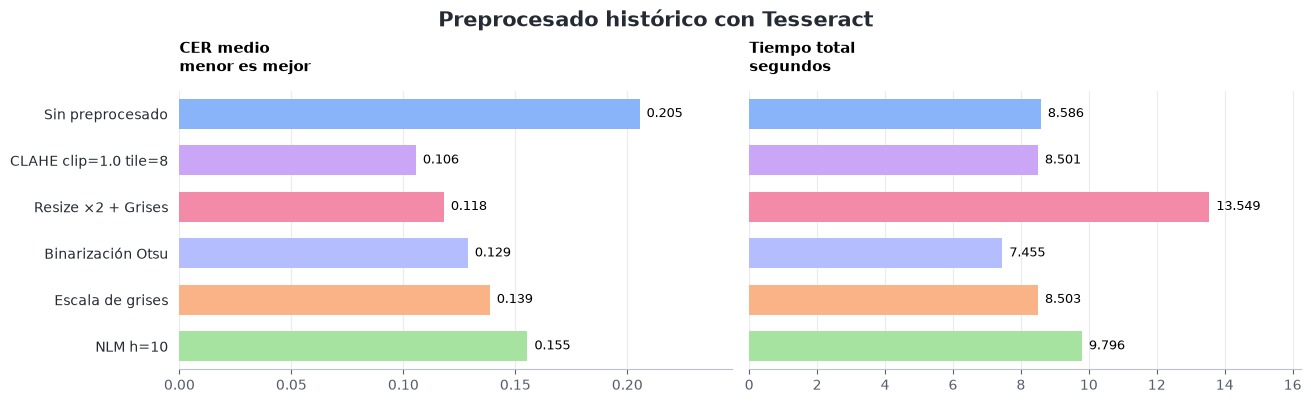

In [4]:
configurations = data["resumen_por_motor"]["tesseract"]
ranking = sorted(
    configurations.values(), key=lambda row: (row["cer_medio"], row["std_cer"])
)
rows = [
    configurations["baseline"],
    *[row for row in ranking if row["tecnica_id"] != "baseline"][:5],
]
show_table(
    rows,
    {
        "tecnica_nombre": "Configuración",
        "cer_medio": "CER",
        "wer_medio": "WER",
        "delta_cer": "Cambio de CER",
        "mejoras_n": "Imágenes que mejoran",
        "t_preprocesado_s": "Preprocesado s",
        "velocidad_s": "Total s",
    },
)
figure = plot_metrics(
    [dict(row, label=row["tecnica_nombre"]) for row in rows],
    [
        ("cer_medio", "CER medio\nmenor es mejor"),
        ("velocidad_s", "Tiempo total\nsegundos"),
    ],
    "Preprocesado histórico con Tesseract",
)
figure

## Conclusiones

La opción elegida para PaddleOCR aumenta la nitidez y mejora las tres imágenes.
Para Tesseract, se elige ampliar la imagen al doble y pasarla a grises.

La configuración de contraste local con menor error medio solo mejora una
imagen. Se descarta porque el criterio exigía mejorar al menos dos.
La muestra es distinta de la comparación ampliada.

Los 134 resultados agregados y los 402 registros por imagen están en `results.json`. [Índice de benchmarks](../../../README.md).

La medición conserva 134 filas agregadas y 402 registros por imagen. Usa otro
corpus que el [estudio ampliado](../benchmark.ipynb), por lo que sus resultados
se presentan por separado.